# Problem 1 — NumPy CNN from Scratch

This solution implements a full Convolutional Neural Network pipeline using **only NumPy** — no PyTorch, TensorFlow, or SciPy convolution utilities.

---

## Components

### i. Convolution Function
`convolve(image, kernel, stride, padding, activation)`

Slides a kernel over a padded `(H, W, C)` input using nested loops, computing the dot product at each position. Supports **sigmoid, tanh, ReLU, and PReLU** activations. Multi-channel inputs are handled naturally since the kernel has the same depth `C` as the input.

### ii. Pooling Function
`pool(activation_map, pool_size, stride, mode)`

Operates on a single 2D activation map. At each window position it takes either the **max** or **mean** of the patch.

### iii. Convolution Layer
`conv_layer(volume, kernels, stride, padding, activation)`

Applies a list of `N` kernels to an input volume and stacks the resulting maps along the channel axis → output shape `(oH, oW, N)`. Output spatial size is verified against the formula $\lfloor(H + 2p - k)/s\rfloor + 1$.

### iv. Pooling Layer
`pool_layer(volume, pool_size, stride, mode)`

Wraps the pooling function to operate **channel-wise** on a full `(H, W, C)` volume.

### v. Flattening
`flatten(volume, output_size)`

Reshapes the volume to a 1D vector (identity mapping), then multiplies by a random weight matrix of shape `(flat_size, output_size)` to project to the desired dimension.

### vi. MLP
`mlp(x, hidden_sizes, output_size, activation)`

Fully connected layers with configurable depth and width. Returns both the **raw logits** and the **softmax probabilities** at the output layer.

### vii. Full CNN Architecture

```
Input (32×32×3)
  → Conv (4 kernels, 5×5, ReLU, same padding)  → 32×32×4
  → MaxPool (2×2, stride 2)                    → 16×16×4
  → Conv (4 kernels, 5×5×4, ReLU, same padding)→ 16×16×4
  → MaxPool (2×2, stride 2)                    → 8×8×4
  → Flatten                                    → 256
  → MLP (hidden=49, ReLU) → output=10, Softmax → 10
```

`"Same"` padding is achieved by setting `padding = (kernel_size - 1) / 2 = 2` for a 5×5 kernel, preserving spatial dimensions across conv layers. All weights are randomly initialised with small values (`~N(0, 0.01)`) to avoid saturation at init.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
# ACTIVATION FUNCTIONS

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def prelu(x, alpha=0.01):
    # Parametric ReLU: negative slope controlled by alpha
    return np.where(x >= 0, x, alpha * x)

def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [3]:
ACTIVATIONS = {"sigmoid": sigmoid, "tanh": tanh, "relu": relu, "prelu": prelu}

In [4]:
# CONVOLUTION FUNCTION

def convolve(image, kernel, stride=1, padding=0, activation="relu"):
    """
    Cross-correlate a (H, W, C) image with a (kH, kW, C) kernel.
    Returns an (oH, oW) activation map after applying the activation.
    """
    act_fn = ACTIVATIONS[activation]
 
    # Pad spatial dims only (not channels)
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding), (0, 0)))
 
    H, W, C = image.shape
    kH, kW, kC = kernel.shape
    assert C == kC, "Image channels must match kernel depth."
 
    oH = (H - kH) // stride + 1
    oW = (W - kW) // stride + 1
    output = np.zeros((oH, oW))
 
    for i in range(oH):
        for j in range(oW):
            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW, :]
            output[i, j] = np.sum(patch * kernel)
 
    return act_fn(output)



def display_convolution(image, kernel, output):
    fig = plt.figure(figsize=(12, 4))
    gs = GridSpec(1, 3, figure=fig)
 
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(image if image.shape[2] == 3 else image[:, :, 0], cmap=None if image.shape[2] == 3 else "gray")
    ax1.set_title("Input Image")
    ax1.axis("off")
 
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(kernel[:, :, 0], cmap="viridis")
    ax2.set_title("Filter Kernel (ch 0)")
    ax2.axis("off")
 
    ax3 = fig.add_subplot(gs[2])
    ax3.imshow(output, cmap="gray")
    ax3.set_title("Output Activation Map")
    ax3.axis("off")
 
    plt.tight_layout()
    plt.savefig("Numpy_CNN\convolution_output.png", dpi=100)
    plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\c'
C:\Users\PUSHKAR\AppData\Local\Temp\ipykernel_44076\3761117243.py:51: SyntaxWarning: invalid escape sequence '\c'
  plt.savefig("Numpy_CNN\convolution_output.png", dpi=100)


In [5]:
# POOLING FUNCTION

def pool(activation_map, pool_size=2, stride=2, mode="max"):
    """
    Pool a single 2D activation map.
    mode: 'max' or 'avg'
    """
    H, W = activation_map.shape
    oH = (H - pool_size) // stride + 1
    oW = (W - pool_size) // stride + 1
    output = np.zeros((oH, oW))
 
    for i in range(oH):
        for j in range(oW):
            patch = activation_map[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            output[i, j] = np.max(patch) if mode == "max" else np.mean(patch)
 
    return output
 
 
def display_pooling(activation_map, pooled):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(activation_map, cmap="gray")
    axes[0].set_title("Input Activation Map")
    axes[0].axis("off")
    axes[1].imshow(pooled, cmap="gray")
    axes[1].set_title("Pooled Output")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("Numpy_CNN\pooling_output.png", dpi=100)
    plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
C:\Users\PUSHKAR\AppData\Local\Temp\ipykernel_44076\549406017.py:30: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig("Numpy_CNN\pooling_output.png", dpi=100)


In [6]:
# CONVOLUTION LAYER FUNCTION

def conv_layer(volume, kernels, stride=1, padding=0, activation="relu"):
    """
    Apply N kernels to an input volume (H, W, C).
    kernels: list of N arrays each shaped (kH, kW, C)
    Returns output volume of shape (oH, oW, N).
    """
    output_maps = [convolve(volume, k, stride, padding, activation) for k in kernels]
    output_volume = np.stack(output_maps, axis=-1)   # shape: (oH, oW, N)
 
    # Verify expected spatial size
    H, W, _ = volume.shape
    kH, kW = kernels[0].shape[:2]
    eH = (H + 2*padding - kH) // stride + 1
    eW = (W + 2*padding - kW) // stride + 1
    assert output_volume.shape[:2] == (eH, eW), "Output spatial size mismatch!"
 
    return output_volume
 
 
def display_conv_layer(volume, kernels, output_volume):
    N = output_volume.shape[2]
    fig, axes = plt.subplots(1, N + 1, figsize=(4*(N+1), 4))
 
    axes[0].imshow(volume if volume.shape[2] == 3 else volume[:, :, 0], cmap=None if volume.shape[2] == 3 else "gray")
    axes[0].set_title("Input Volume (ch 0)" if volume.shape[2] != 3 else "Input Volume")
    axes[0].axis("off")
 
    for i in range(N):
        axes[i+1].imshow(output_volume[:, :, i], cmap="gray")
        axes[i+1].set_title(f"Output Map {i+1}")
        axes[i+1].axis("off")
 
    plt.tight_layout()
    plt.savefig("Numpy_CNN\conv_layer_output.png", dpi=100)
    plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
C:\Users\PUSHKAR\AppData\Local\Temp\ipykernel_44076\3256509626.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.savefig("Numpy_CNN\conv_layer_output.png", dpi=100)


In [7]:
# POOLING LAYER FUNCTION

def pool_layer(volume, pool_size=2, stride=2, mode="max"):
    """
    Apply pooling independently to each channel of a volume (H, W, C).
    Returns pooled volume of shape (oH, oW, C).
    """
    pooled_maps = [pool(volume[:, :, c], pool_size, stride, mode) for c in range(volume.shape[2])]
    return np.stack(pooled_maps, axis=-1)
 
 
def display_pool_layer(volume, pooled_volume):
    C = volume.shape[2]
    fig, axes = plt.subplots(2, C, figsize=(4*C, 8))
    for c in range(C):
        axes[0, c].imshow(volume[:, :, c], cmap="gray")
        axes[0, c].set_title(f"Input ch {c+1}")
        axes[0, c].axis("off")
        axes[1, c].imshow(pooled_volume[:, :, c], cmap="gray")
        axes[1, c].set_title(f"Pooled ch {c+1}")
        axes[1, c].axis("off")
    plt.tight_layout()
    plt.savefig("Numpy_CNN\pool_layer_output.png", dpi=100)
    plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\PUSHKAR\AppData\Local\Temp\ipykernel_44076\227011070.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig("Numpy_CNN\pool_layer_output.png", dpi=100)


In [8]:
# Flattening Function

def flatten(volume, output_size):
    """
    Flatten volume to 1D, then project to output_size via a random weight matrix.
    Weight shape: (flattened_size, output_size)
    """
    flat = volume.flatten()                          # identity mapping (no activation)
    W = np.random.randn(flat.shape[0], output_size) * 0.01
    return flat @ W, W  

In [9]:
# MLP

def mlp(x, hidden_sizes, output_size, activation="relu"):
    """
    x           : input vector
    hidden_sizes: list of ints, one per hidden layer
    output_size : number of output nodes
    Returns (raw_output, softmax_output, weights_list)
    """
    act_fn = ACTIVATIONS[activation]
    weights = []
    current = x
 
    # Hidden layers
    for size in hidden_sizes:
        W = np.random.randn(current.shape[0], size) * 0.01
        b = np.zeros(size)
        current = act_fn(current @ W + b)
        weights.append((W, b))
 
    # Output layer (no activation before softmax)
    W_out = np.random.randn(current.shape[0], output_size) * 0.01
    b_out = np.zeros(output_size)
    raw = current @ W_out + b_out
    weights.append((W_out, b_out))
 
    return raw, softmax(raw), weights

In [10]:
# FULL FEED-FORWARD CNN

def build_cnn(image):
    """
    Architecture for CIFAR-10 (32x32x3 input):
      Conv(4 kernels, 5x5, ReLU, stride=1, same padding)
      MaxPool(2x2, stride=2)
      Conv(4 kernels, 5x5x4, ReLU, stride=1, same padding)
      MaxPool(2x2, stride=2)
      Flatten (identity)
      MLP: hidden=[49], output=10, ReLU + softmax
    """
    print(f"Input shape     : {image.shape}")
 
    # --- Conv Layer 1: 4 kernels of 5x5x3, padding=2 for 'same' ---
    kernels1 = [np.random.randn(5, 5, 3) * 0.01 for _ in range(4)]
    vol1 = conv_layer(image, kernels1, stride=1, padding=2, activation="relu")
    print(f"After Conv1     : {vol1.shape}")   # should be 32x32x4
 
    # --- MaxPool Layer 1: 2x2, stride=2 ---
    vol2 = pool_layer(vol1, pool_size=2, stride=2, mode="max")
    print(f"After Pool1     : {vol2.shape}")   # should be 16x16x4
 
    # --- Conv Layer 2: 4 kernels of 5x5x4, padding=2 for 'same' ---
    kernels2 = [np.random.randn(5, 5, 4) * 0.01 for _ in range(4)]
    vol3 = conv_layer(vol2, kernels2, stride=1, padding=2, activation="relu")
    print(f"After Conv2     : {vol3.shape}")   # should be 16x16x4
 
    # --- MaxPool Layer 2: 2x2, stride=2 ---
    vol4 = pool_layer(vol3, pool_size=2, stride=2, mode="max")
    print(f"After Pool2     : {vol4.shape}")   # should be 8x8x4 => 256 values
 
    # --- Flatten (identity: just reshape, no activation) ---
    flat = vol4.flatten()
    print(f"After Flatten   : {flat.shape}")   # 256
 
    # --- MLP: hidden=[49], output=10, ReLU + softmax ---
    raw_out, softmax_out, _ = mlp(flat, hidden_sizes=[49], output_size=10, activation="relu")
    print(f"MLP raw output  : {raw_out.shape}")
    print(f"Softmax output  : {softmax_out.shape}")
    print(f"Softmax sums to : {softmax_out.sum():.6f}")
 
    return softmax_out


i) Convolution Function
  [sigmoid ] output shape: (8, 8)
  [tanh    ] output shape: (8, 8)
  [relu    ] output shape: (8, 8)
  [prelu   ] output shape: (8, 8)


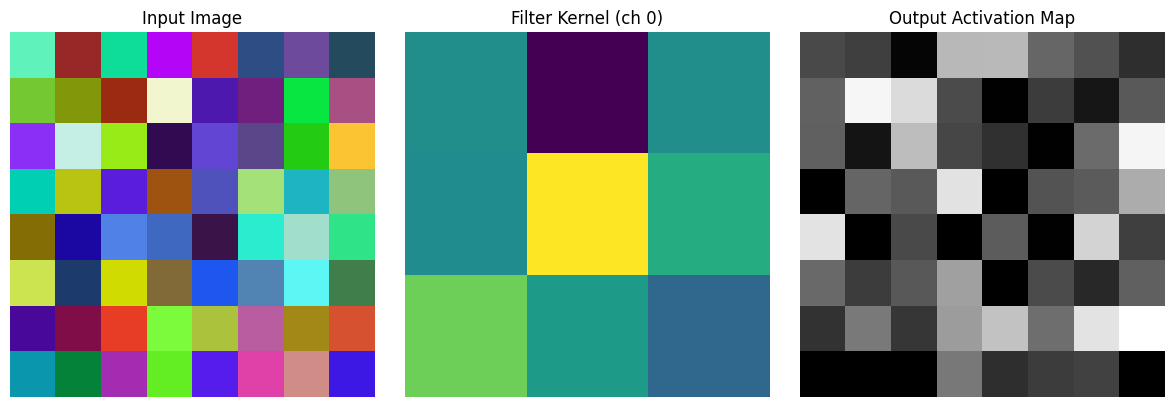


ii) Pooling Function
  Input: (8, 8)  →  Pooled: (4, 4)


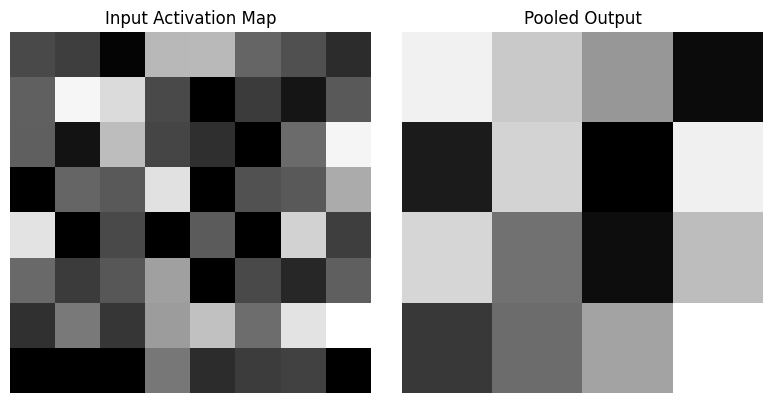


iii) Convolution Layer
  Output volume shape: (8, 8, 4)  (expected 8x8x4)


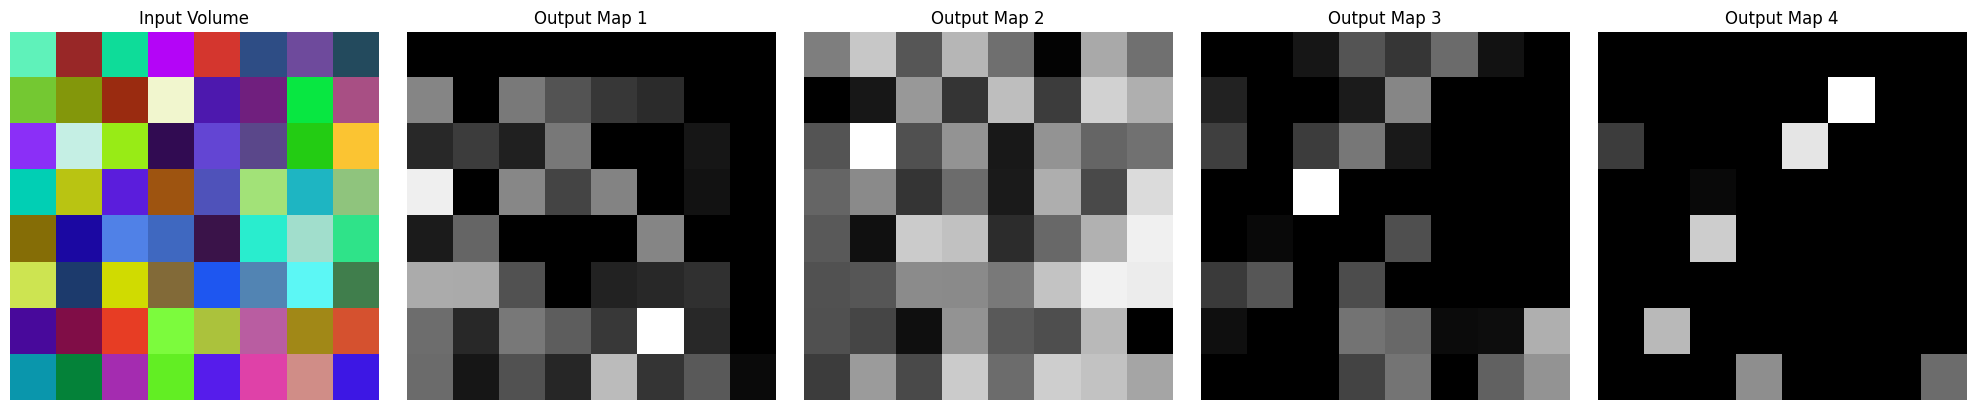


iv) Pooling Layer
  Pooled volume shape: (4, 4, 4)  (expected 4x4x4)


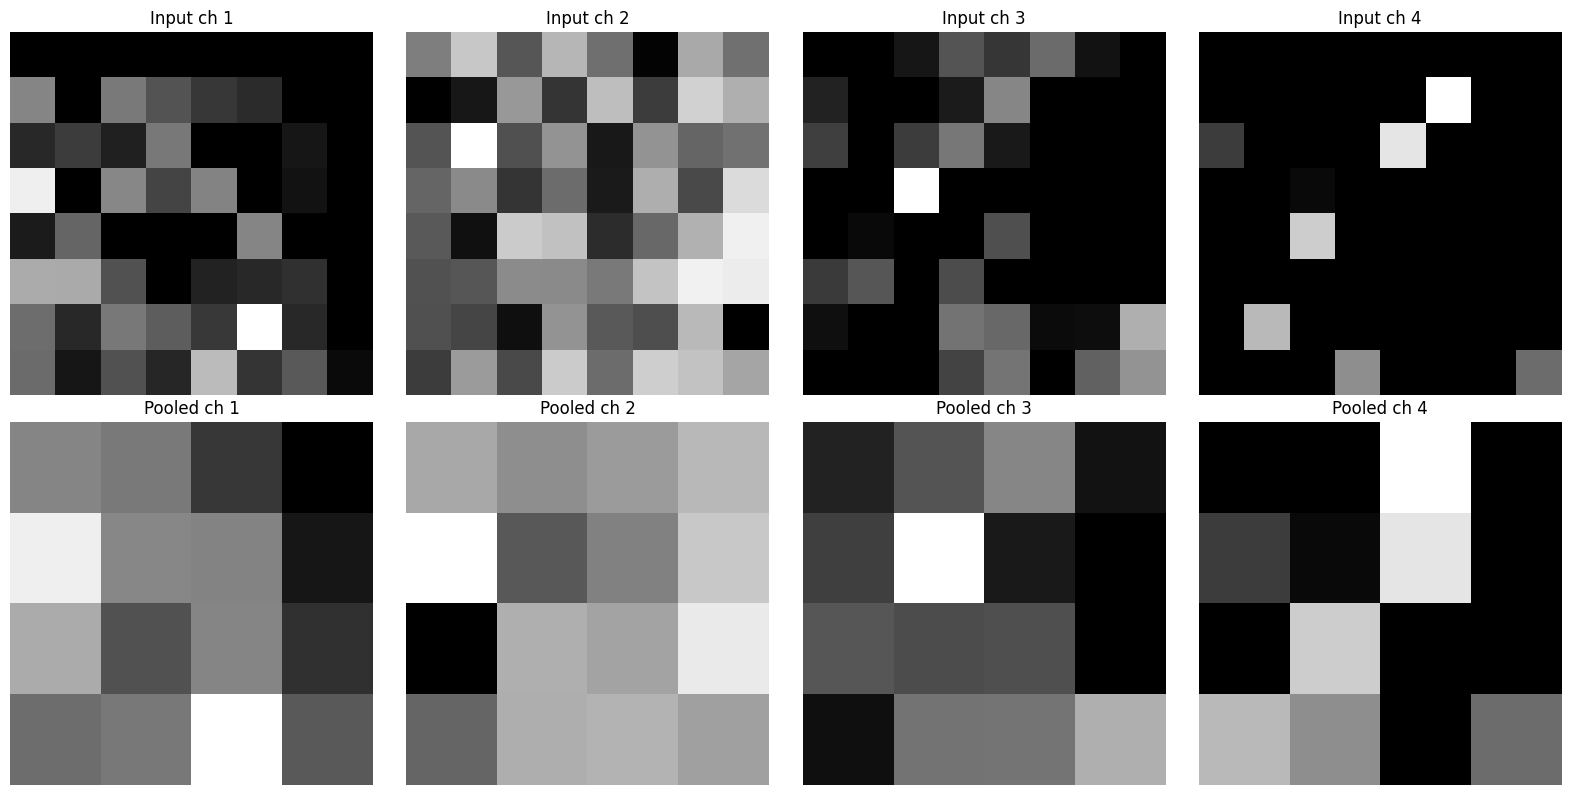


v) Flattening
  Flat vector shape: (32,)  (from volume (4, 4, 4))

vi) MLP
  Raw output : (10,)  |  Softmax: (10,)  |  Sum: 1.000000

vii) Full CNN on CIFAR-10 (32x32x3)
Input shape     : (32, 32, 3)
After Conv1     : (32, 32, 4)
After Pool1     : (16, 16, 4)
After Conv2     : (16, 16, 4)
After Pool2     : (8, 8, 4)
After Flatten   : (256,)
MLP raw output  : (10,)
Softmax output  : (10,)
Softmax sums to : 1.000000

Final output vector (10 classes):
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [11]:
np.random.seed(42)

# ---------- i) Convolution Function ----------
print("i) Convolution Function")
img = np.random.rand(8, 8, 3)          # small test image
kernel = np.random.randn(3, 3, 3)
for act in ["sigmoid", "tanh", "relu", "prelu"]:
    out = convolve(img, kernel, stride=1, padding=1, activation=act)
    print(f"  [{act:8s}] output shape: {out.shape}")
display_convolution(img, kernel, out)

# ---------- ii) Pooling Function ----------
print("\nii) Pooling Function")
act_map = convolve(img, kernel, stride=1, padding=1, activation="relu")
pooled = pool(act_map, pool_size=2, stride=2, mode="max")
print(f"  Input: {act_map.shape}  →  Pooled: {pooled.shape}")
display_pooling(act_map, pooled)

# ---------- iii) Convolution Layer ----------
print("\niii) Convolution Layer")
kernels = [np.random.randn(3, 3, 3) for _ in range(4)]
vol_out = conv_layer(img, kernels, stride=1, padding=1, activation="relu")
print(f"  Output volume shape: {vol_out.shape}  (expected 8x8x4)")
display_conv_layer(img, kernels, vol_out)

# ---------- iv) Pooling Layer ----------
print("\niv) Pooling Layer")
pooled_vol = pool_layer(vol_out, pool_size=2, stride=2, mode="max")
print(f"  Pooled volume shape: {pooled_vol.shape}  (expected 4x4x4)")
display_pool_layer(vol_out, pooled_vol)

# ---------- v) Flattening ----------
print("\nv) Flattening")
flat_vec, W_flat = flatten(pooled_vol, output_size=32)
print(f"  Flat vector shape: {flat_vec.shape}  (from volume {pooled_vol.shape})")

# ---------- vi) MLP ----------
print("\nvi) MLP")
raw, sm, _ = mlp(flat_vec, hidden_sizes=[16, 8], output_size=10, activation="relu")
print(f"  Raw output : {raw.shape}  |  Softmax: {sm.shape}  |  Sum: {sm.sum():.6f}")

# ---------- vii) Full CNN on CIFAR-10 image ----------
print("\nvii) Full CNN on CIFAR-10 (32x32x3)")
print("=" * 50)
cifar_image = np.random.rand(32, 32, 3)
output = build_cnn(cifar_image)
print(f"\nFinal output vector (10 classes):\n{np.round(output, 4)}")

# Problem 2 — PyTorch CNN Training & Experiments

This solution re-uses the same architecture from Q1 (part vii) but now trains it end-to-end with PyTorch's autograd. All weights are randomly initialised (PyTorch default: Kaiming uniform).

---

## Architecture & Loss

The `CNN` class mirrors the Q1 design exactly:

```
Conv(3→4, 5×5, same) → ReLU → MaxPool(2×2)
Conv(4→4, 5×5, same) → ReLU → MaxPool(2×2)
Flatten (256-d)
FC(256→49) → [BN] → ReLU → [Dropout] → FC(49→10)
```

**Loss:** `nn.CrossEntropyLoss` — this fuses log-softmax + NLL loss, so no explicit softmax is needed in the forward pass. Labels are class indices (PyTorch's convention); one-hot encoding is handled internally.

---

## Parts

### a) Training Setup
100 images/class from train set (1000 total), 10/class from test set (100 total). Data is shuffled each epoch via `DataLoader(shuffle=True)`. Default batch size: 32.

### b) Optimizers (3 variants, all η = 0.001)
| | Config |
|---|---|
| **SGD** | vanilla, no momentum |
| **Momentum SGD** | α = 0.9 |
| **RMSProp** | ρ = 0.9 |

Each is trained for 15 epochs. Loss and accuracy on both train and test sets are recorded after every epoch and plotted together for comparison.

### c) Per-Epoch Diagnostics
- **Loss/Accuracy curves** — plotted at the end of all runs on the same axes for easy comparison.
- **Activation maps** — after each run, a representative slice (one image, all 4 channels) from both conv layers is visualised as a heatmap.
- **Classification accuracy** — printed at each epoch and reported finally.

### d) tSNE of Bottleneck Features
The 49-d hidden representation (after ReLU of `fc1`) is extracted for all 100 test images at **epoch 1** and **epoch 15**. tSNE projects these to 2D — cleaner cluster separation at the last epoch indicates the network has learned more discriminative features.

### e) Dropout
Dropout is applied **after** the ReLU of the hidden layer, at rates `p ∈ {0.0, 0.2, 0.5, 0.8}`, trained with RMSProp. Higher dropout typically reduces overfitting (smaller train–test gap) at the cost of slower convergence.

### f) Batch Normalisation
BN is inserted **before** the ReLU of `fc1` (i.e. on raw pre-activations), then dropout (p=0.2) follows. Three configurations are compared:

| Model | BN | Dropout |
|---|---|---|
| Vanilla | ✗ | ✗ |
| Dropout only | ✗ | 0.2 |
| BN + Dropout | ✓ | 0.2 |

BN normalises the hidden layer's input distribution, reducing internal covariate shift and generally leading to faster convergence and better generalisation.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.manifold import TSNE

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# DATA LOADING

def get_subset(dataset, n_per_class, n_classes=10):
    """Return indices selecting exactly n_per_class samples for each class."""
    indices = []
    counts = {c: 0 for c in range(n_classes)}
    for idx, (_, label) in enumerate(dataset):
        if counts[label] < n_per_class:
            indices.append(idx)
            counts[label] += 1
        if all(v == n_per_class for v in counts.values()):
            break
    return indices
 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
 
full_train = datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform)
full_test  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
 
train_set = Subset(full_train, get_subset(full_train, n_per_class=100))
test_set  = Subset(full_test,  get_subset(full_test,  n_per_class=10))

In [15]:
#  CNN Model  (same architecture as Q1 part vii)

class CNN(nn.Module):
    def __init__(self, dropout_p=0.0, use_bn=False):
        super().__init__()
 
        # --- Convolutional backbone ---
        self.conv1 = nn.Conv2d(3, 4, kernel_size=5, stride=1, padding=2)   # 32x32x3 → 32x32x4
        self.conv2 = nn.Conv2d(4, 4, kernel_size=5, stride=1, padding=2)   # 16x16x4 → 16x16x4
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)                  # halves spatial dims
        self.relu  = nn.ReLU()
 
        # After two pool layers: 32 → 16 → 8, so flat size = 8*8*4 = 256
        self.use_bn    = use_bn
        self.dropout_p = dropout_p
 
        self.fc1 = nn.Linear(256, 49)
        self.bn1 = nn.BatchNorm1d(49) if use_bn else nn.Identity()
        self.drop = nn.Dropout(p=dropout_p) if dropout_p > 0 else nn.Identity()
        self.fc2 = nn.Linear(49, 10)
 
        # Activation maps storage (populated during forward)
        self.act1 = None
        self.act2 = None
 
    def forward(self, x):
        x = self.relu(self.conv1(x))
        self.act1 = x.detach()                  # save conv1 activations
        x = self.pool(x)
 
        x = self.relu(self.conv2(x))
        self.act2 = x.detach()                  # save conv2 activations
        x = self.pool(x)
 
        x = x.view(x.size(0), -1)               # flatten: (B, 256)
 
        # BN applied before non-linearity, dropout after
        x = self.drop(self.relu(self.bn1(self.fc1(x))))
        x = self.fc2(x)                          # raw logits (CrossEntropyLoss handles softmax)
        return x
 
    def get_bottleneck(self, x):
        """Return the 49-dim hidden representation (after ReLU) for tSNE."""
        with torch.no_grad():
            x = self.pool(self.relu(self.conv1(x)))
            x = self.pool(self.relu(self.conv2(x)))
            x = x.view(x.size(0), -1)
            x = self.relu(self.bn1(self.fc1(x)))
        return x.cpu().numpy()

In [16]:
# TRAINING LOOP

def train(model, optimizer, n_epochs=15, batch_size=32):
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_set,  batch_size=len(test_set))
 
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
 
    # Grab test data once for tSNE
    test_imgs, test_labels = next(iter(test_loader))
    test_imgs, test_labels = test_imgs.to(device), test_labels.to(device)
 
    tsne_features = {}
 
    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss, correct, total = 0.0, 0, 0
 
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
 
            ep_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total   += imgs.size(0)
 
        train_losses.append(ep_loss / total)
        train_accs.append(correct / total)
 
        # --- Evaluate on test set ---
        model.eval()
        with torch.no_grad():
            test_out  = model(test_imgs)
            test_loss = criterion(test_out, test_labels).item()
            test_acc  = (test_out.argmax(1) == test_labels).float().mean().item()
 
        test_losses.append(test_loss)
        test_accs.append(test_acc)
 
        print(f"Epoch {epoch:2d} | Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.3f}"
              f" | Test Loss: {test_loss:.4f}  Acc: {test_acc:.3f}")
 
        # Save bottleneck features at epoch 1 and last epoch for tSNE
        if epoch == 1 or epoch == n_epochs:
            tsne_features[epoch] = (model.get_bottleneck(test_imgs), test_labels.cpu().numpy())
 
    return train_losses, test_losses, train_accs, test_accs, tsne_features, model

In [17]:
# VISUALISATION

def plot_loss_acc(results_dict, title=""):
    """Plot train/test loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, (tr_l, te_l, tr_a, te_a, _, _) in results_dict.items():
        epochs = range(1, len(tr_l) + 1)
        axes[0].plot(epochs, tr_l, label=f"{label} train")
        axes[0].plot(epochs, te_l, "--", label=f"{label} test")
        axes[1].plot(epochs, tr_a, label=f"{label} train")
        axes[1].plot(epochs, te_a, "--", label=f"{label} test")
 
    axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    for ax in axes:
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
 
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"Pytorch_CNN/Loss_Acc/loss_acc_{title.replace(' ', '_')}.png", dpi=100)
    plt.show()


def visualize_activation_maps(model, title=""):
    """Show one representative slice from each conv layer's activation volume."""
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(f"Activation Maps — {title}")
 
    for i in range(4):
        axes[0, i].imshow(model.act1[0, i].cpu(), cmap="viridis")
        axes[0, i].set_title(f"Conv1 ch {i+1}")
        axes[0, i].axis("off")
 
        axes[1, i].imshow(model.act2[0, i].cpu(), cmap="viridis")
        axes[1, i].set_title(f"Conv2 ch {i+1}")
        axes[1, i].axis("off")
 
    plt.tight_layout()
    plt.savefig(f"Pytorch_CNN/Activations/activations_{title.replace(' ', '_')}.png", dpi=100)
    plt.show()


def plot_tsne(tsne_features, title=""):
    """tSNE of bottleneck features at epoch 1 and last epoch."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    CIFAR10_CLASSES = ["plane","car","bird","cat","deer","dog","frog","horse","ship","truck"]
 
    for ax, (epoch, (feats, labels)) in zip(axes, sorted(tsne_features.items())):
        embedded = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(feats)
        scatter = ax.scatter(embedded[:, 0], embedded[:, 1], c=labels, cmap="tab10", s=20)
        ax.set_title(f"tSNE — Epoch {epoch}")
        ax.axis("off")
 
    # Shared colorbar legend
    handles = [plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=plt.cm.tab10(i/10), markersize=8, label=CIFAR10_CLASSES[i])
               for i in range(10)]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8)
    fig.suptitle(f"Bottleneck tSNE — {title}")
    plt.tight_layout()
    plt.savefig(f"Pytorch_CNN/tsne/tsne_{title.replace(' ', '_')}.png", dpi=100)
    plt.show()

In [18]:
# BUILD MODEL + RUN EXPERIMENT

def run_experiment(opt_name, dropout_p=0.0, use_bn=False, batch_size=32, n_epochs=15):
    print(f"\n{'='*55}")
    print(f"  Optimizer: {opt_name} | dropout: {dropout_p} | BN: {use_bn}")
    print(f"{'='*55}")
 
    model = CNN(dropout_p=dropout_p, use_bn=use_bn).to(device)
    # Random init is PyTorch default (Kaiming uniform for Linear/Conv)
 
    if opt_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.001)
    elif opt_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    elif opt_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001, alpha=0.9)
 
    return train(model, optimizer, n_epochs=n_epochs, batch_size=batch_size)


  Optimizer: SGD | dropout: 0.0 | BN: False
Epoch  1 | Train Loss: 2.3039  Acc: 0.110 | Test Loss: 2.3040  Acc: 0.090
Epoch  2 | Train Loss: 2.3037  Acc: 0.112 | Test Loss: 2.3039  Acc: 0.090
Epoch  3 | Train Loss: 2.3036  Acc: 0.113 | Test Loss: 2.3038  Acc: 0.090
Epoch  4 | Train Loss: 2.3035  Acc: 0.111 | Test Loss: 2.3036  Acc: 0.090
Epoch  5 | Train Loss: 2.3033  Acc: 0.112 | Test Loss: 2.3035  Acc: 0.100
Epoch  6 | Train Loss: 2.3032  Acc: 0.113 | Test Loss: 2.3034  Acc: 0.100
Epoch  7 | Train Loss: 2.3031  Acc: 0.113 | Test Loss: 2.3032  Acc: 0.100
Epoch  8 | Train Loss: 2.3029  Acc: 0.113 | Test Loss: 2.3031  Acc: 0.100
Epoch  9 | Train Loss: 2.3028  Acc: 0.113 | Test Loss: 2.3030  Acc: 0.100
Epoch 10 | Train Loss: 2.3026  Acc: 0.111 | Test Loss: 2.3028  Acc: 0.110
Epoch 11 | Train Loss: 2.3024  Acc: 0.112 | Test Loss: 2.3027  Acc: 0.100
Epoch 12 | Train Loss: 2.3023  Acc: 0.110 | Test Loss: 2.3025  Acc: 0.110
Epoch 13 | Train Loss: 2.3021  Acc: 0.109 | Test Loss: 2.3023  Acc:

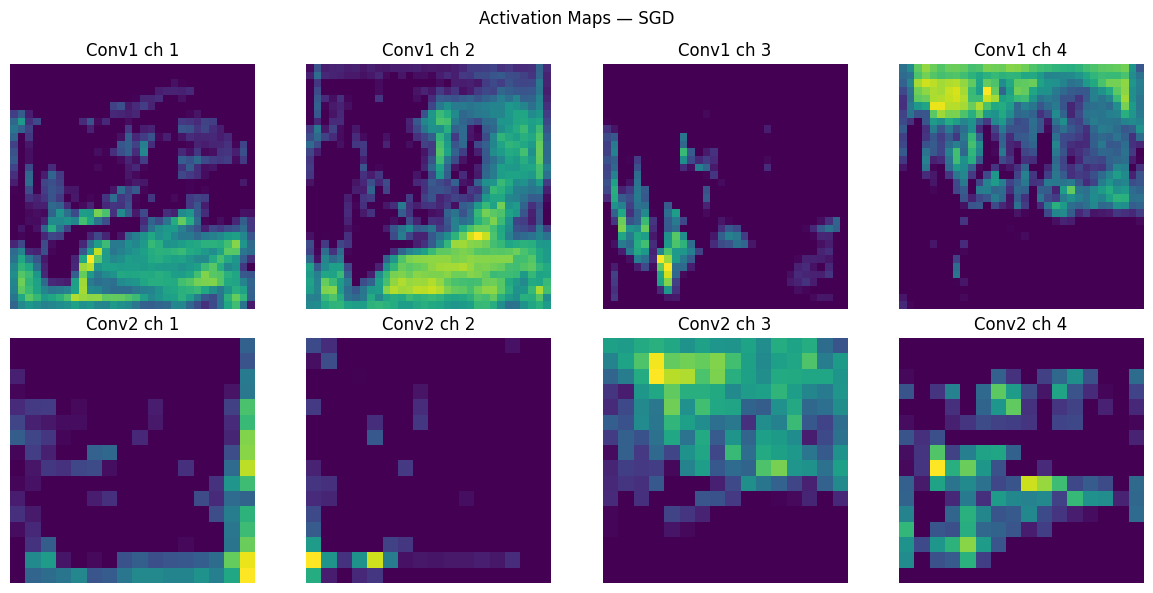

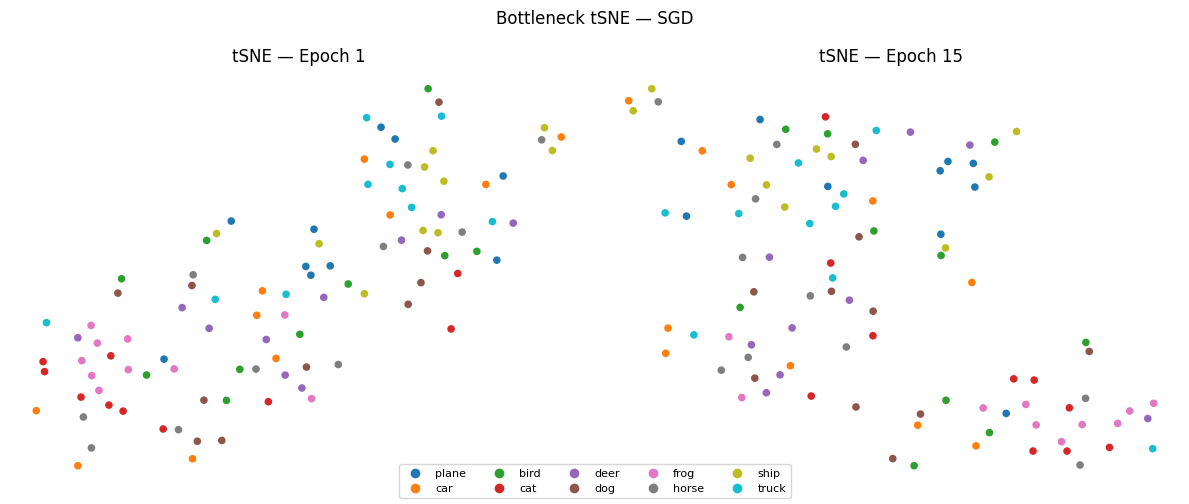

  Final Test Accuracy [SGD]: 0.110

  Optimizer: Momentum | dropout: 0.0 | BN: False
Epoch  1 | Train Loss: 2.3063  Acc: 0.100 | Test Loss: 2.3074  Acc: 0.110
Epoch  2 | Train Loss: 2.3056  Acc: 0.099 | Test Loss: 2.3068  Acc: 0.110
Epoch  3 | Train Loss: 2.3050  Acc: 0.102 | Test Loss: 2.3064  Acc: 0.110
Epoch  4 | Train Loss: 2.3043  Acc: 0.103 | Test Loss: 2.3058  Acc: 0.110
Epoch  5 | Train Loss: 2.3036  Acc: 0.102 | Test Loss: 2.3053  Acc: 0.110
Epoch  6 | Train Loss: 2.3029  Acc: 0.102 | Test Loss: 2.3048  Acc: 0.110
Epoch  7 | Train Loss: 2.3022  Acc: 0.105 | Test Loss: 2.3043  Acc: 0.110
Epoch  8 | Train Loss: 2.3013  Acc: 0.105 | Test Loss: 2.3037  Acc: 0.100
Epoch  9 | Train Loss: 2.3004  Acc: 0.109 | Test Loss: 2.3031  Acc: 0.090
Epoch 10 | Train Loss: 2.2994  Acc: 0.115 | Test Loss: 2.3022  Acc: 0.100
Epoch 11 | Train Loss: 2.2980  Acc: 0.120 | Test Loss: 2.3011  Acc: 0.090
Epoch 12 | Train Loss: 2.2964  Acc: 0.123 | Test Loss: 2.2996  Acc: 0.100
Epoch 13 | Train Loss: 2.29

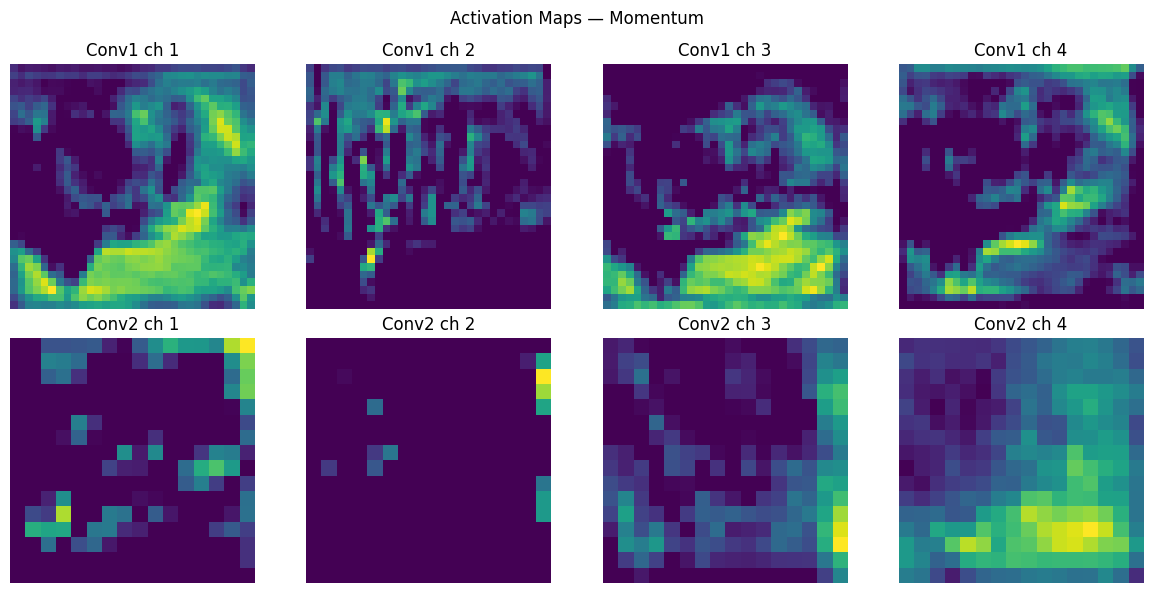

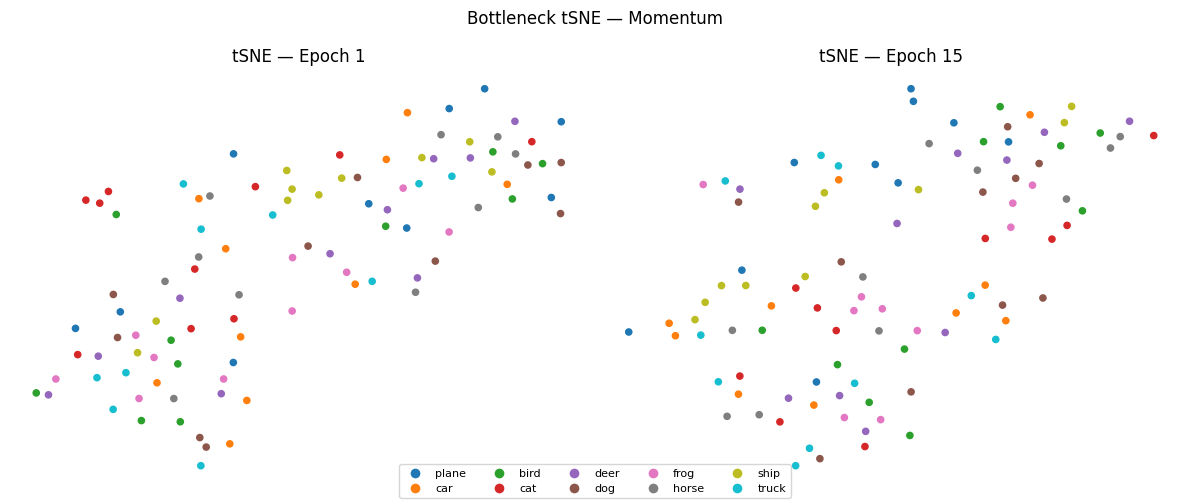

  Final Test Accuracy [Momentum]: 0.130

  Optimizer: RMSProp | dropout: 0.0 | BN: False
Epoch  1 | Train Loss: 2.2651  Acc: 0.144 | Test Loss: 2.1413  Acc: 0.220
Epoch  2 | Train Loss: 2.0785  Acc: 0.232 | Test Loss: 2.0554  Acc: 0.230
Epoch  3 | Train Loss: 1.9821  Acc: 0.280 | Test Loss: 2.0086  Acc: 0.330
Epoch  4 | Train Loss: 1.9265  Acc: 0.306 | Test Loss: 1.9573  Acc: 0.300
Epoch  5 | Train Loss: 1.8749  Acc: 0.332 | Test Loss: 1.9503  Acc: 0.350
Epoch  6 | Train Loss: 1.8230  Acc: 0.352 | Test Loss: 1.9463  Acc: 0.260
Epoch  7 | Train Loss: 1.7760  Acc: 0.363 | Test Loss: 1.9966  Acc: 0.340
Epoch  8 | Train Loss: 1.7491  Acc: 0.376 | Test Loss: 1.9077  Acc: 0.340
Epoch  9 | Train Loss: 1.7126  Acc: 0.369 | Test Loss: 1.8928  Acc: 0.380
Epoch 10 | Train Loss: 1.6794  Acc: 0.393 | Test Loss: 1.9095  Acc: 0.360
Epoch 11 | Train Loss: 1.6516  Acc: 0.409 | Test Loss: 1.9276  Acc: 0.300
Epoch 12 | Train Loss: 1.6281  Acc: 0.425 | Test Loss: 1.9392  Acc: 0.350
Epoch 13 | Train Loss: 

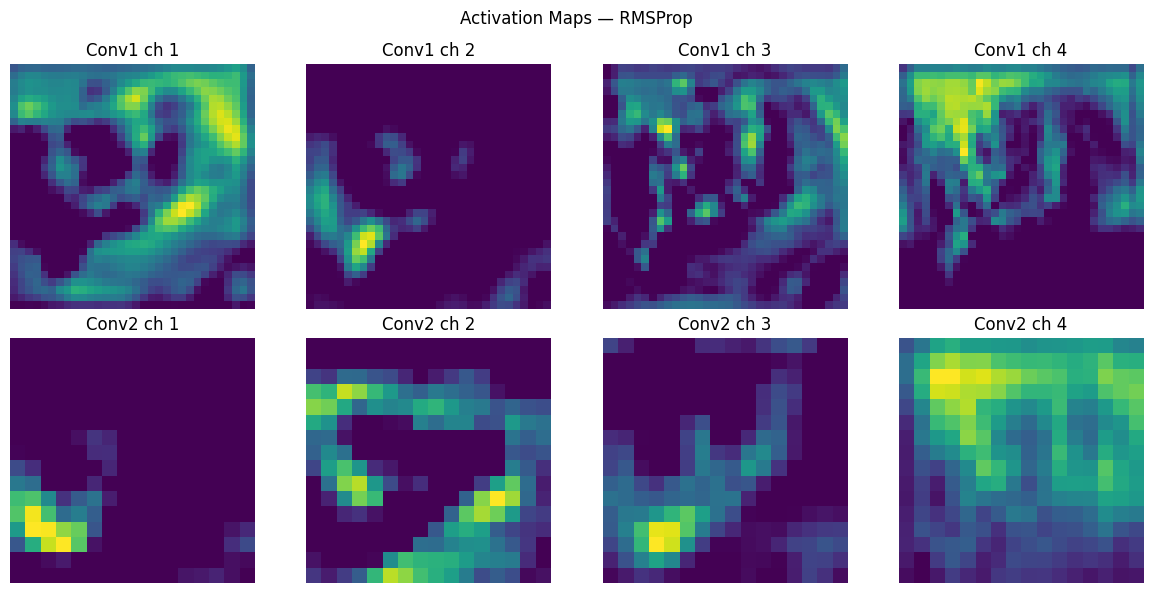

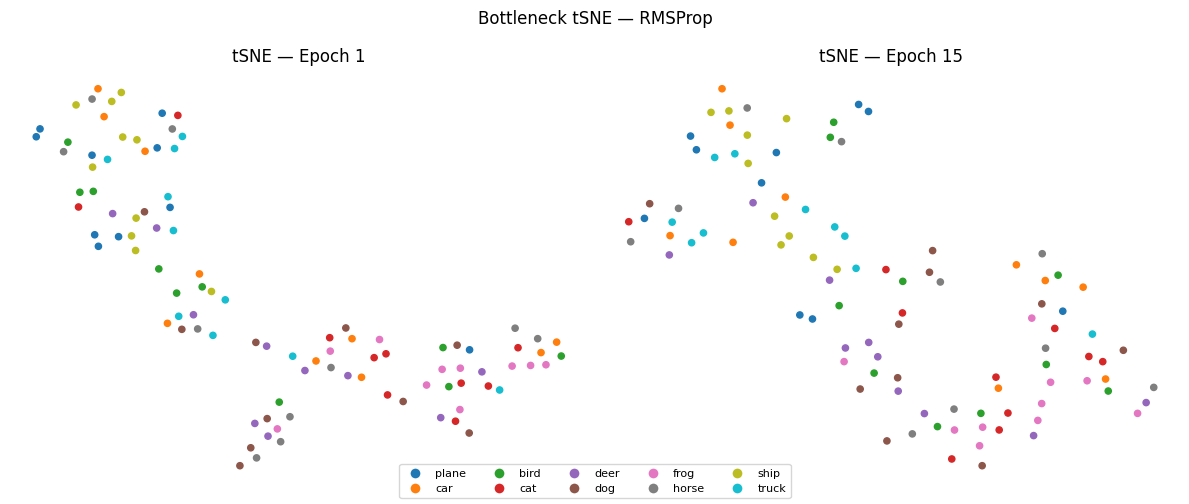

  Final Test Accuracy [RMSProp]: 0.350


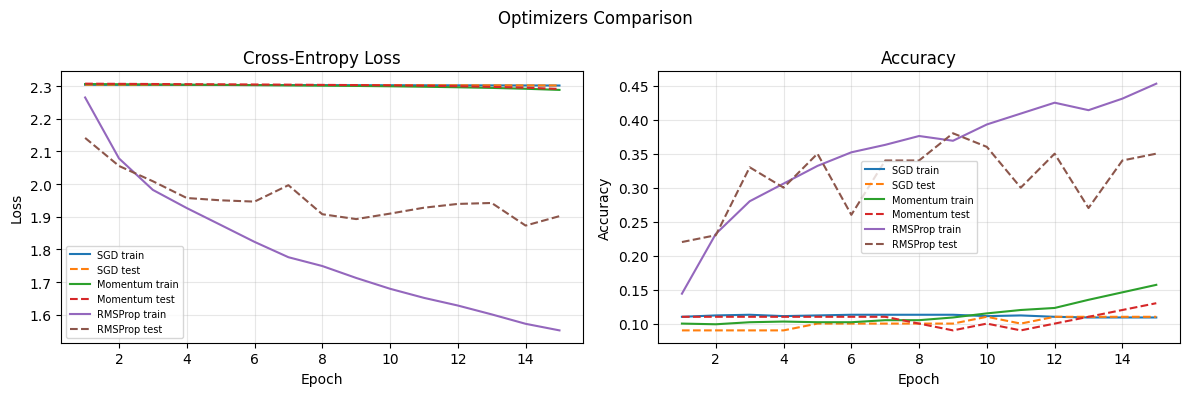

In [19]:
# TRAIN WITH 3 OPTIMIZERS AND PLOT RESULTS

results_optim = {}
for opt in ["SGD", "Momentum", "RMSProp"]:
    tr_l, te_l, tr_a, te_a, tsne_f, model = run_experiment(opt, batch_size=32)
    results_optim[opt] = (tr_l, te_l, tr_a, te_a, tsne_f, model)
    visualize_activation_maps(model, title=opt)
    plot_tsne(tsne_f, title=opt)
    print(f"  Final Test Accuracy [{opt}]: {te_a[-1]:.3f}")
 
plot_loss_acc({k: v[:4] + v[4:] for k, v in results_optim.items()}, title="Optimizers Comparison")



--- Part e) Dropout Experiment ---

  Optimizer: RMSProp | dropout: 0.0 | BN: False
Epoch  1 | Train Loss: 2.2700  Acc: 0.151 | Test Loss: 2.1834  Acc: 0.200
Epoch  2 | Train Loss: 2.0816  Acc: 0.267 | Test Loss: 2.1099  Acc: 0.270
Epoch  3 | Train Loss: 1.9861  Acc: 0.296 | Test Loss: 2.0683  Acc: 0.280
Epoch  4 | Train Loss: 1.9217  Acc: 0.313 | Test Loss: 2.0371  Acc: 0.320
Epoch  5 | Train Loss: 1.8692  Acc: 0.335 | Test Loss: 1.9673  Acc: 0.260
Epoch  6 | Train Loss: 1.8120  Acc: 0.353 | Test Loss: 1.9226  Acc: 0.320
Epoch  7 | Train Loss: 1.7616  Acc: 0.375 | Test Loss: 1.9395  Acc: 0.320
Epoch  8 | Train Loss: 1.7077  Acc: 0.379 | Test Loss: 1.9052  Acc: 0.240
Epoch  9 | Train Loss: 1.6740  Acc: 0.414 | Test Loss: 1.9669  Acc: 0.240
Epoch 10 | Train Loss: 1.6237  Acc: 0.425 | Test Loss: 1.8984  Acc: 0.310
Epoch 11 | Train Loss: 1.5824  Acc: 0.437 | Test Loss: 1.9702  Acc: 0.310
Epoch 12 | Train Loss: 1.5483  Acc: 0.453 | Test Loss: 2.0126  Acc: 0.290
Epoch 13 | Train Loss: 1.5

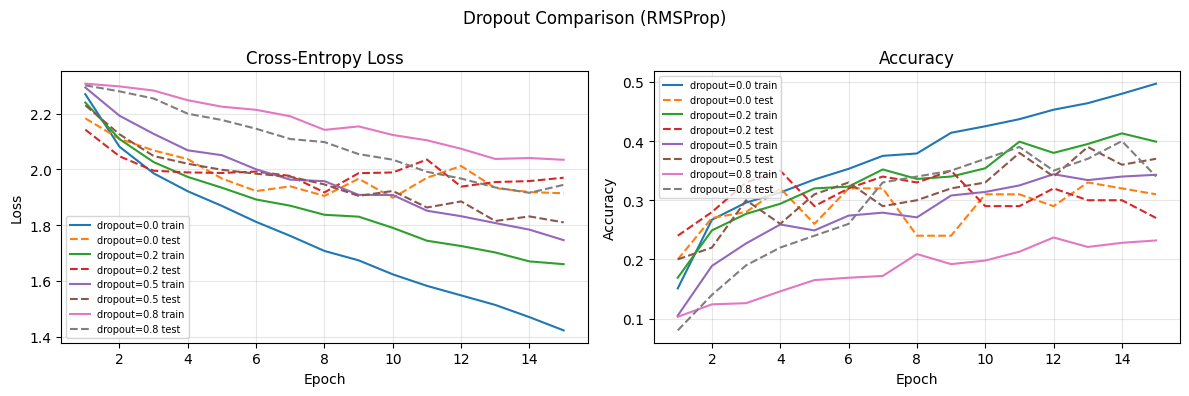

In [20]:
# e) DROPOUT EXPERIMENT (RMSProp)

print("\n\n--- Part e) Dropout Experiment ---")
dropout_results = {}
for p in [0.0, 0.2, 0.5, 0.8]:
    label = f"dropout={p}"
    tr_l, te_l, tr_a, te_a, tsne_f, model = run_experiment("RMSProp", dropout_p=p)
    dropout_results[label] = (tr_l, te_l, tr_a, te_a, tsne_f, model)
    print(f"  Final Test Accuracy [dropout={p}]: {te_a[-1]:.3f}")
 
plot_loss_acc(dropout_results, title="Dropout Comparison (RMSProp)")



--- Part f) BatchNorm + Dropout Experiment ---

  Optimizer: RMSProp | dropout: 0.0 | BN: False
Epoch  1 | Train Loss: 2.2770  Acc: 0.127 | Test Loss: 2.2010  Acc: 0.190
Epoch  2 | Train Loss: 2.0717  Acc: 0.264 | Test Loss: 2.0041  Acc: 0.280
Epoch  3 | Train Loss: 1.9415  Acc: 0.310 | Test Loss: 1.9469  Acc: 0.260
Epoch  4 | Train Loss: 1.8760  Acc: 0.350 | Test Loss: 1.9595  Acc: 0.370
Epoch  5 | Train Loss: 1.8209  Acc: 0.356 | Test Loss: 1.9211  Acc: 0.330
Epoch  6 | Train Loss: 1.7704  Acc: 0.370 | Test Loss: 1.9628  Acc: 0.280
Epoch  7 | Train Loss: 1.7292  Acc: 0.395 | Test Loss: 2.0155  Acc: 0.330
Epoch  8 | Train Loss: 1.6809  Acc: 0.415 | Test Loss: 1.8392  Acc: 0.330
Epoch  9 | Train Loss: 1.6278  Acc: 0.427 | Test Loss: 1.8857  Acc: 0.380
Epoch 10 | Train Loss: 1.6050  Acc: 0.415 | Test Loss: 1.8664  Acc: 0.320
Epoch 11 | Train Loss: 1.5468  Acc: 0.455 | Test Loss: 1.8402  Acc: 0.340
Epoch 12 | Train Loss: 1.5085  Acc: 0.480 | Test Loss: 1.8472  Acc: 0.330
Epoch 13 | Tra

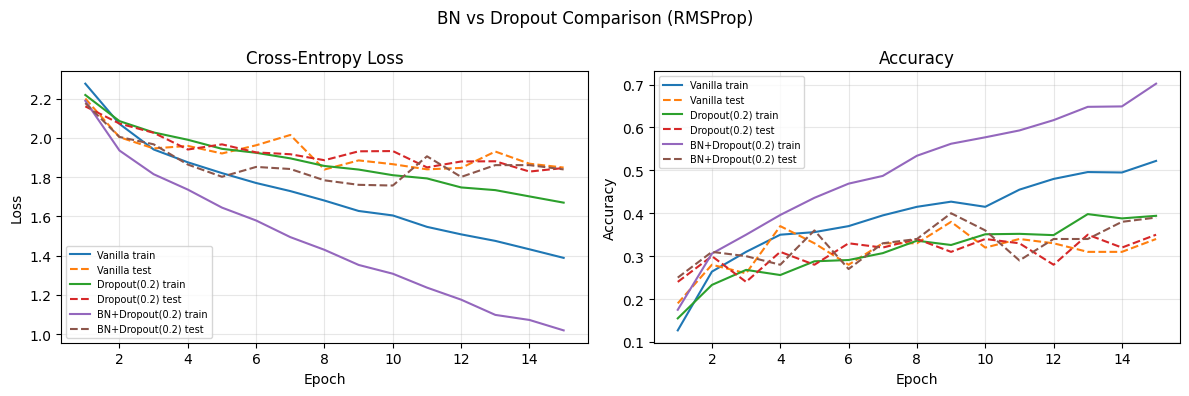

In [21]:
# f) BATCH NORM + DROPOUT EXPERIMENT

print("\n\n--- Part f) BatchNorm + Dropout Experiment ---")
bn_results = {}
for label, dp, bn in [("Vanilla", 0.0, False), ("Dropout(0.2)", 0.2, False), ("BN+Dropout(0.2)", 0.2, True)]:
    tr_l, te_l, tr_a, te_a, tsne_f, model = run_experiment("RMSProp", dropout_p=dp, use_bn=bn)
    bn_results[label] = (tr_l, te_l, tr_a, te_a, tsne_f, model)
    print(f"  Final Test Accuracy [{label}]: {te_a[-1]:.3f}")
 
plot_loss_acc(bn_results, title="BN vs Dropout Comparison (RMSProp)")

# Problem 3 — Backpropagation in CNN (Theory)

---

## (i) Network Flow Diagram

```
X (8×8) → [Conv1, 3×3, pad=1] → Z₁ → ReLU → A₁ → [MaxPool 2×2, s=2] → P₁
        → [Conv2, 3×3, 2 filters, no pad] → Z₂ → ReLU → A₂
        → Flatten → F → [FC: W, b] → Z₃ → Sigmoid → ŷ
        → BCE Loss L
```

---

## (ii) Dimensions of Each Tensor

Using the formula: $\text{out} = \lfloor (n + 2p - k)/s \rfloor + 1$

| Tensor | Shape | Derivation |
|--------|-------|-----------|
| $Z_1$ | $8 \times 8$ | $(8 + 2(1) - 3)/1 + 1 = 8$ — same padding preserves spatial dims |
| $A_1$ | $8 \times 8$ | ReLU is element-wise, shape unchanged |
| $P_1$ | $4 \times 4$ | $(8 - 2)/2 + 1 = 4$ — max-pool halves each dimension |
| $Z_2$ | $2 \times 2 \times 2$ | $(4 - 3)/1 + 1 = 2$; 2 filters → 2 channels |
| $A_2$ | $2 \times 2 \times 2$ | ReLU, shape unchanged |
| $F$   | $8$ | Flattened: $2 \times 2 \times 2 = 8$ |
| $Z_3$ | scalar | FC projects $\mathbb{R}^8 \to \mathbb{R}^1$ |
| $\hat{y}$ | scalar | $\sigma(Z_3) \in (0,1)$ |

---

## (iii) Trainable Parameters

**Conv Layer 1** (single filter, 3×3, grayscale input + bias):
$$3 \times 3 \times 1 + 1 = 10$$

**Conv Layer 2** (2 filters, 3×3, applied to 1-channel $P_1$, each with bias):
$$2 \times (3 \times 3 \times 1 + 1) = 20$$

**FC Layer** ($W$: 8×1, $b$: 1):
$$8 \times 1 + 1 = 9$$

$$\boxed{\text{Total} = 10 + 20 + 9 = 39 \text{ trainable parameters}}$$

---

## (iv) Backpropagation — Gradient Derivations

### Setup: BCE Loss

$$L = -\left[y \log \hat{y} + (1-y)\log(1-\hat{y})\right], \quad \hat{y} = \sigma(Z_3)$$

A key identity: the gradient of BCE through sigmoid simplifies cleanly:
$$\frac{\partial L}{\partial Z_3} = \hat{y} - y$$

---

### FC Layer Parameters $(W, b)$

$$Z_3 = W \cdot F + b$$

$$\boxed{\frac{\partial L}{\partial W} = (\hat{y} - y) \cdot F^T}$$

$$\boxed{\frac{\partial L}{\partial b} = \hat{y} - y}$$

Gradient flowing back into the flatten layer:

$$\frac{\partial L}{\partial F} = W^T \cdot (\hat{y} - y)$$

This is reshaped to $2 \times 2 \times 2$ to match $A_2$.

---

### Conv Layer 2 Parameters

Let $\delta_{A_2} = \frac{\partial L}{\partial A_2}$ (reshaped $\frac{\partial L}{\partial F}$). Backprop through ReLU:

$$\delta_{Z_2} = \delta_{A_2} \odot \mathbf{1}[Z_2 > 0]$$

where $\odot$ is element-wise multiplication and $\mathbf{1}[Z_2 > 0]$ is the ReLU mask.

For filter $k$ of Conv2 (size $3 \times 3$), the gradient is a **cross-correlation** of the input $P_1$ with the upstream error:

$$\boxed{\frac{\partial L}{\partial K_2^{(k)}} = P_1 \star \delta_{Z_2}^{(k)}}$$

where $\star$ denotes valid cross-correlation. Each bias gradient:
$$\frac{\partial L}{\partial b_2^{(k)}} = \sum_{i,j} \delta_{Z_2}^{(k)}[i,j]$$

Gradient propagated back to $P_1$ (summed over both filters, using full convolution):
$$\frac{\partial L}{\partial P_1} = \sum_k K_2^{(k)} \circledast \delta_{Z_2}^{(k)}$$

where $\circledast$ denotes full convolution (180°-flipped kernel, zero-padded).

---

### Conv Layer 1 Parameters

Gradient through MaxPool: only the positions that were selected as the max in the forward pass receive gradient; all others receive zero.

$$\frac{\partial L}{\partial A_1}[i,j] = \begin{cases} \frac{\partial L}{\partial P_1}[i',j'] & \text{if } (i,j) \text{ was the argmax in pool window } (i', j') \\ 0 & \text{otherwise} \end{cases}$$

Backprop through ReLU:
$$\delta_{Z_1} = \frac{\partial L}{\partial A_1} \odot \mathbf{1}[Z_1 > 0]$$

Gradient for the Conv1 kernel (cross-correlation of original input $X$ with upstream error):

$$\boxed{\frac{\partial L}{\partial K_1} = X \star \delta_{Z_1}}$$

Since Conv1 uses padding=1, $X$ is first zero-padded before the correlation. Bias gradient:

$$\frac{\partial L}{\partial b_1} = \sum_{i,j} \delta_{Z_1}[i,j]$$

---

### Summary of Gradient Flow

$$L \xrightarrow{\hat{y}-y} Z_3 \xrightarrow{\times F^T} W,b \xrightarrow{\times W^T} F \xrightarrow{\text{reshape}} A_2 \xrightarrow{\odot \text{ReLU mask}} Z_2 \xrightarrow{\star P_1} K_2, b_2 \xrightarrow{\circledast K_2} P_1 \xrightarrow{\text{MaxPool mask}} A_1 \xrightarrow{\odot \text{ReLU mask}} Z_1 \xrightarrow{\star X} K_1, b_1$$